Julieta Madrigal Flores


Rodolfo Del Castillo Wilches

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tk = yf.Ticker('SPY')
S0 = tk.fast_info['last_price']
exp = '2026-04-17'
K = 680

calls = tk.option_chain(exp).calls
puts = tk.option_chain(exp).puts

row_call = calls[calls['strike'] == K].iloc[0]
row_put = puts[puts['strike'] == K].iloc[0]

C = (row_call['bid'] + row_call['ask']) / 2
P = (row_put['bid'] + row_put['ask']) / 2

print(f"Subyacente (S0): {S0:.2f} | Strike (K): {K}")
print(f"Call Mid (C): {C:.4f} | Put Mid (P): {P:.4f}")




Subyacente (S0): 653.18 | Strike (K): 680
Call Mid (C): 3.4100 | Put Mid (P): 28.4350


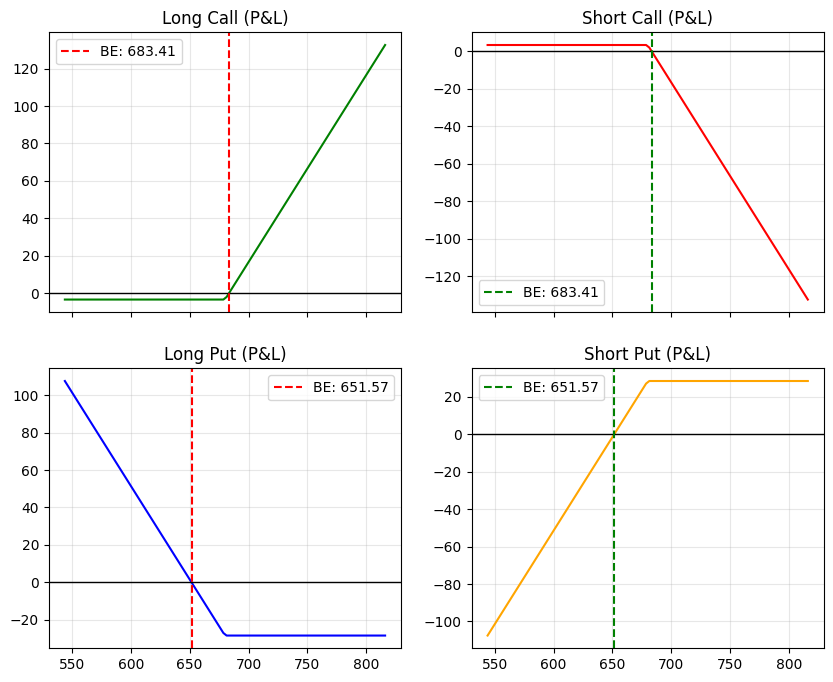

In [3]:
S = np.linspace(K * 0.8, K * 1.2, 100)

long_call = np.maximum(S - K, 0) - C
short_call = -long_call
long_put = np.maximum(K - S, 0) - P
short_put = -long_put

fig, ax = plt.subplots(2, 2, figsize=(10, 8), sharex=True)

ax[0, 0].plot(S, long_call, color='green')
ax[0, 0].set_title('Long Call (P&L)')
ax[0, 0].axhline(0, color='black', lw=1)
ax[0, 0].axvline(K + C, color='red', linestyle='--', label=f'BE: {K+C:.2f}')

ax[0, 1].plot(S, short_call, color='red')
ax[0, 1].set_title('Short Call (P&L)')
ax[0, 1].axhline(0, color='black', lw=1)
ax[0, 1].axvline(K + C, color='green', linestyle='--', label=f'BE: {K+C:.2f}')

ax[1, 0].plot(S, long_put, color='blue')
ax[1, 0].set_title('Long Put (P&L)')
ax[1, 0].axhline(0, color='black', lw=1)
ax[1, 0].axvline(K - P, color='red', linestyle='--', label=f'BE: {K-P:.2f}')

ax[1, 1].plot(S, short_put, color='orange')
ax[1, 1].set_title('Short Put (P&L)')
ax[1, 1].axhline(0, color='black', lw=1)
ax[1, 1].axvline(K - P, color='green', linestyle='--', label=f'BE: {K-P:.2f}')

for a in ax.flat:
    a.grid(True, alpha=0.3)
    a.legend()

In [4]:
data_be = {
    "Posición": ["Long Call", "Short Call", "Long Put", "Short Put"],
    "Break-Even Formula": ["K + C", "K + C", "K - P", "K - P"],
    "Valor BE": [K + C, K + C, K - P, K - P]
}
df_be = pd.DataFrame(data_be)
df_be

,Posición,Break-Even Formula,Valor BE
0,Long Call,K + C,683.410
1,Short Call,K + C,683.410
2,Long Put,K - P,651.565
3,Short Put,K - P,651.565


Con el S0 actual, ¿cuál de las cuatro posiciones básicas tiene el break-even más cercano al precio actual? ¿Qué implica eso?

- Con el $S_0$ actual la posición con el Break-even más cercano al precio actual es la Long Put o la Short Put.


Si SPY termina exactamente en K al vencimiento, ¿cuánto gana o pierde cada posición? ¿Por qué?
- Si el SPY cierra exactamente en $680$ al vencimiento:

Compara la pérdida máxima de una long call vs. una short put. ¿Cuál tiene más riesgo? ¿Por qué?
  

- La Short Put tiene mucho más riesgo.

- En la Long Call, mi pérdida está topada al 100% de lo que pagué ($C$) siendo un riesgo controlado. En la Short Put, aunque cobro una prima, estoy obligado a comprar el activo a $K$ si el precio cae.

¿En qué escenario de mercado elegirías una long put sobre una short call, si ambas expresan una visión bajista?


- Elegiría Long Put ante proyecciones de alta volatilidad o caídas agresivas, maximizando la ganancia mediante una Vega positiva y un Delta direccional. En cambio, optaría por Short Call en mercados moderadamente bajistas para capitalizar el Theta decay, priorizando el valor extrínseco sobre el movimiento del subyacente.